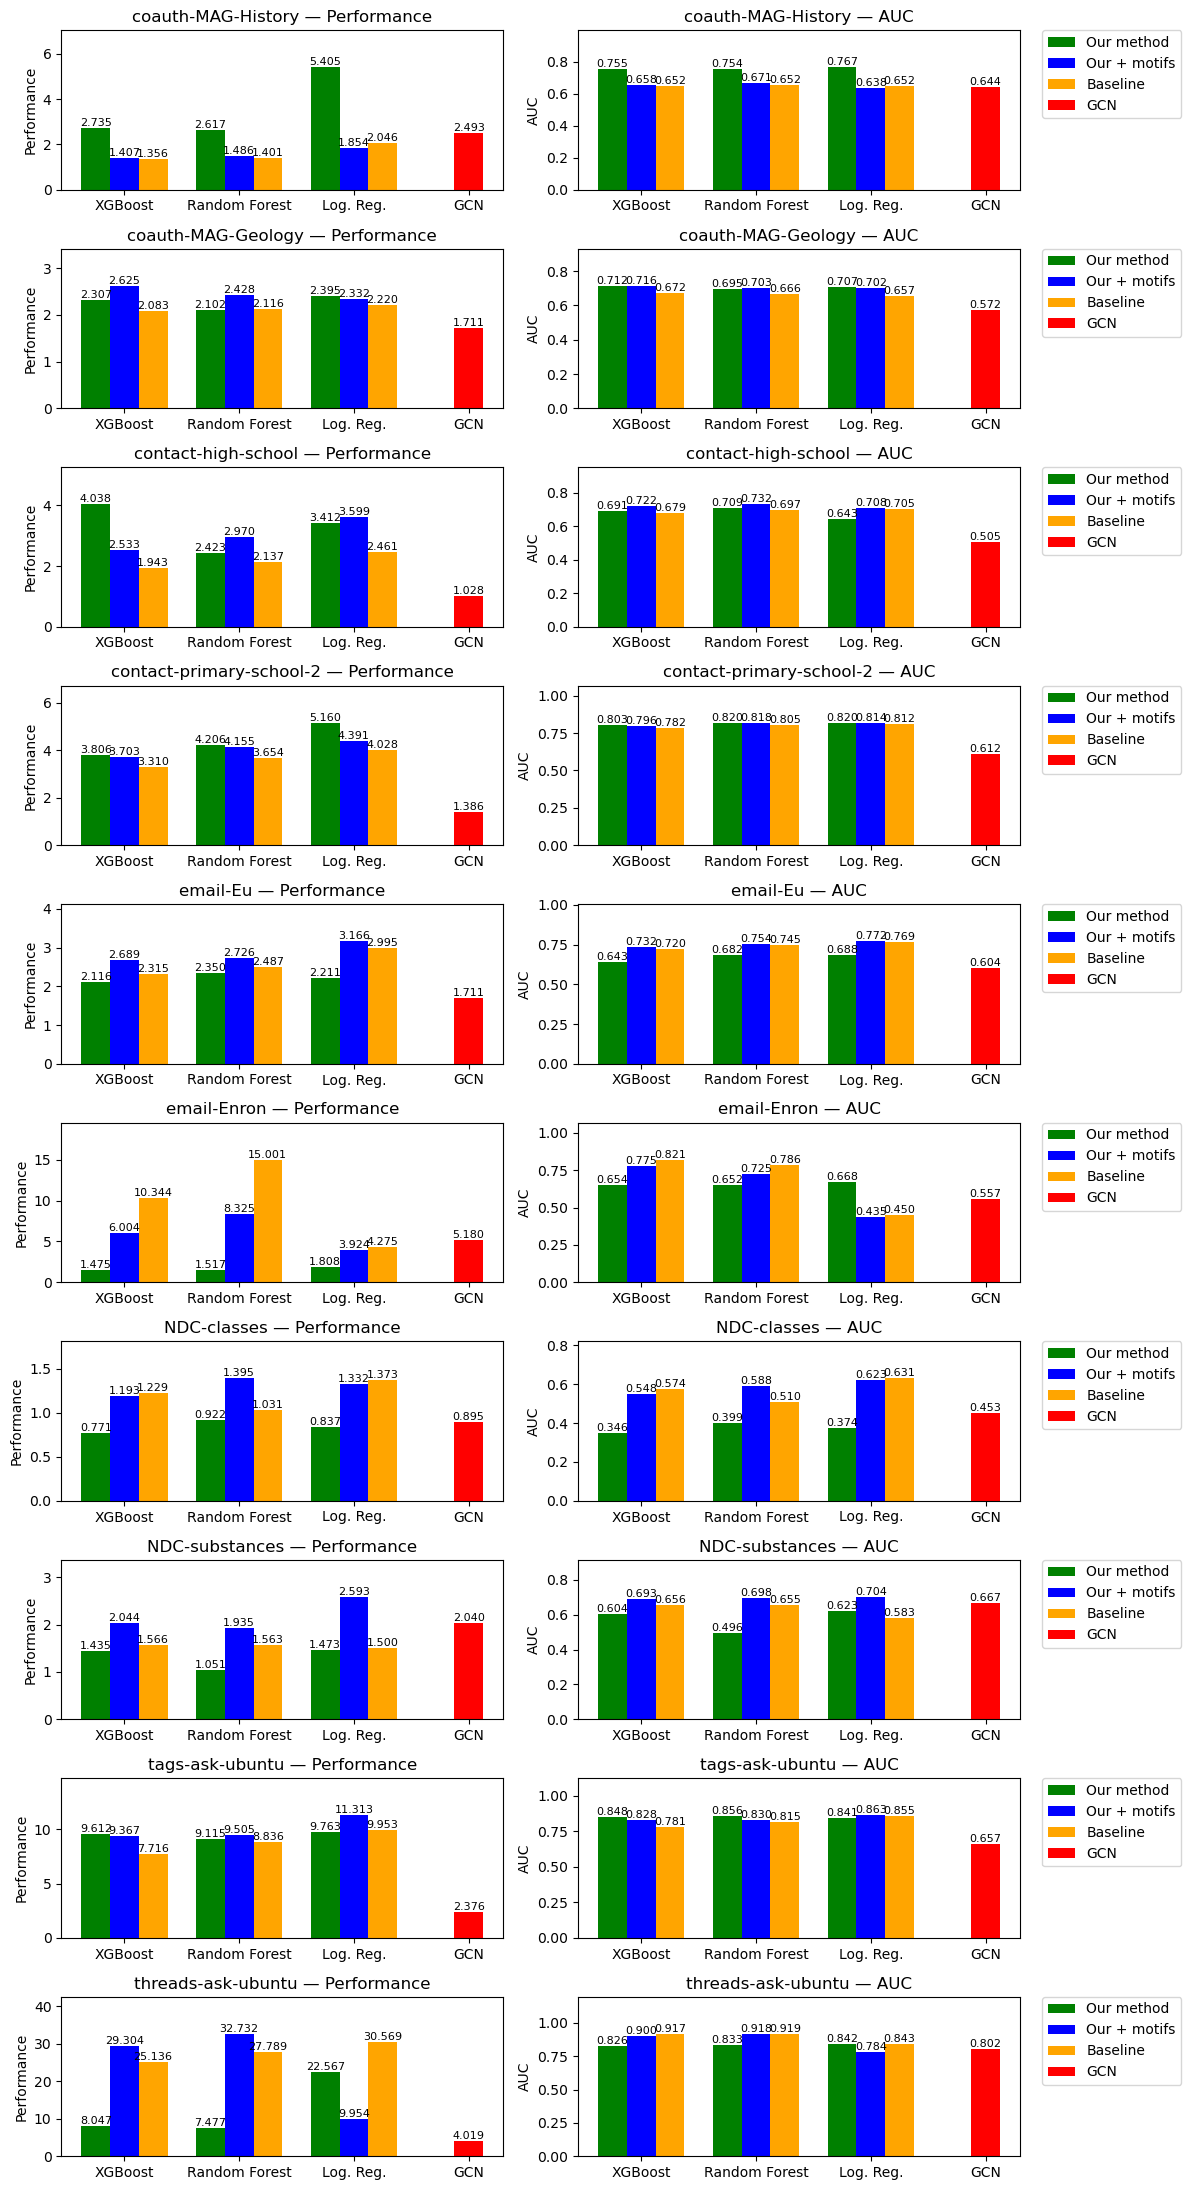

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Datasets and methods
datasets = [
    "coauth-MAG-History",
    "coauth-MAG-Geology",
    "contact-high-school",
    "contact-primary-school-2",
    "email-Eu",
    "email-Enron",
    "NDC-classes",
    "NDC-substances",
    "tags-ask-ubuntu",
    "threads-ask-ubuntu"
]
methods = ["xgb", "rf", "lr"]
method_labels = ["XGBoost", "Random Forest", "Log. Reg.", "GCN"]
metrics = ["performance", "auc"]
metric_labels = {"performance": "Performance", "auc": "AUC"}

# Base paths
our_base = Path("results_our/time")
our_motifs_base = Path("results_our_and_motifs/time")
baseline_base = Path("baseline/results_baseline/time")
gnn_base = Path("results_gnn/time")

# Function to read a single CSV and return a dict with values
def read_metrics(path: Path):
    df = pd.read_csv(path)
    return df.iloc[0].to_dict()  # single row

# Collect data
data = []
for dataset in datasets:
    for method in methods:
        our_path = our_base / dataset / "metrics" / f"test_{method}.csv"
        our_motifs_path = our_motifs_base / dataset / "metrics" / f"test_{method}.csv"
        base_path = baseline_base / dataset / "metrics" / f"test_{method}.csv"

        our_metrics = read_metrics(our_path)
        our_motifs_metrics = read_metrics(our_motifs_path)
        base_metrics = read_metrics(base_path)

        data.append({
            "dataset": dataset,
            "method": method,
            "type": "our",
            "performance": our_metrics["performance"],
            "auc": our_metrics["auc"],
        })
        data.append({
            "dataset": dataset,
            "method": method,
            "type": "our_motifs",
            "performance": our_motifs_metrics["performance"],
            "auc": our_motifs_metrics["auc"],
        })
        data.append({
            "dataset": dataset,
            "method": method,
            "type": "baseline",
            "performance": base_metrics["performance"],
            "auc": base_metrics["auc"],
        })

    gnn_path = gnn_base / dataset / "metrics" / f"test_gcn.csv"
    gnn_metrics = read_metrics(gnn_path)
    data.append({
        "dataset": dataset,
        "method": 'GCN',
        "type": "GCN",
        "performance": gnn_metrics["performance"],
        "auc": gnn_metrics["auc"],
    })
        
# Convert to DataFrame
df = pd.DataFrame(data)

# --- Plotting ---
fig, axes = plt.subplots(nrows=len(datasets), ncols=2, figsize=(12, 22))
fig.subplots_adjust(hspace=0.4, wspace=0.25)

for i, dataset in enumerate(datasets):
    for j, metric in enumerate(metrics):
        ax = axes[i, j]
        subset = df[df["dataset"] == dataset]

        x = range(len(methods))
        width = 0.25  # 3 słupki obok siebie

        our_vals = [
            subset[(subset["method"] == m) & (subset["type"] == "our")][metric].values[0]
            for m in methods
        ]
        our_motifs_vals = [
            subset[(subset["method"] == m) & (subset["type"] == "our_motifs")][metric].values[0]
            for m in methods
        ]
        base_vals = [
            subset[(subset["method"] == m) & (subset["type"] == "baseline")][metric].values[0]
            for m in methods
        ]

        gnn_vals = [
            subset[(subset["method"] == 'GCN') & (subset["type"] == "GCN")][metric].values[0]
        ]

        # kolejność: our (lewo), our+motifs (środek), baseline (prawo)
        bars_our = ax.bar(
            [p - width for p in x],
            our_vals,
            width,
            label="Our method",
            color="green",
        )
        bars_our_motifs = ax.bar(
            x,
            our_motifs_vals,
            width,
            label="Our + motifs",
            color="blue",
        )
        bars_base = ax.bar(
            [p + width for p in x],
            base_vals,
            width,
            label="Baseline",
            color="orange",
        )

        bars_gnn = ax.bar(
            [3],
            gnn_vals,
            width,
            label="GCN",
            color="red",
        )

        # Add numbers above bars
        for bar in list(bars_our) + list(bars_our_motifs) + list(bars_base) + list(bars_gnn):
            height = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height,
                f"{height:.3f}",
                ha="center",
                va="bottom",
                fontsize=8,
            )

        ax.set_title(f"{dataset} — {metric_labels[metric]}")
        ax.set_xticks(range(4))
        ax.set_xticklabels(method_labels)
        ax.set_ylabel(metric_labels[metric])
        ax.set_ymargin(0.3)

        if j == 1:
            ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout()
plt.savefig('performance_auc.pdf', format="pdf", bbox_inches="tight")
plt.show()

# n_motifs

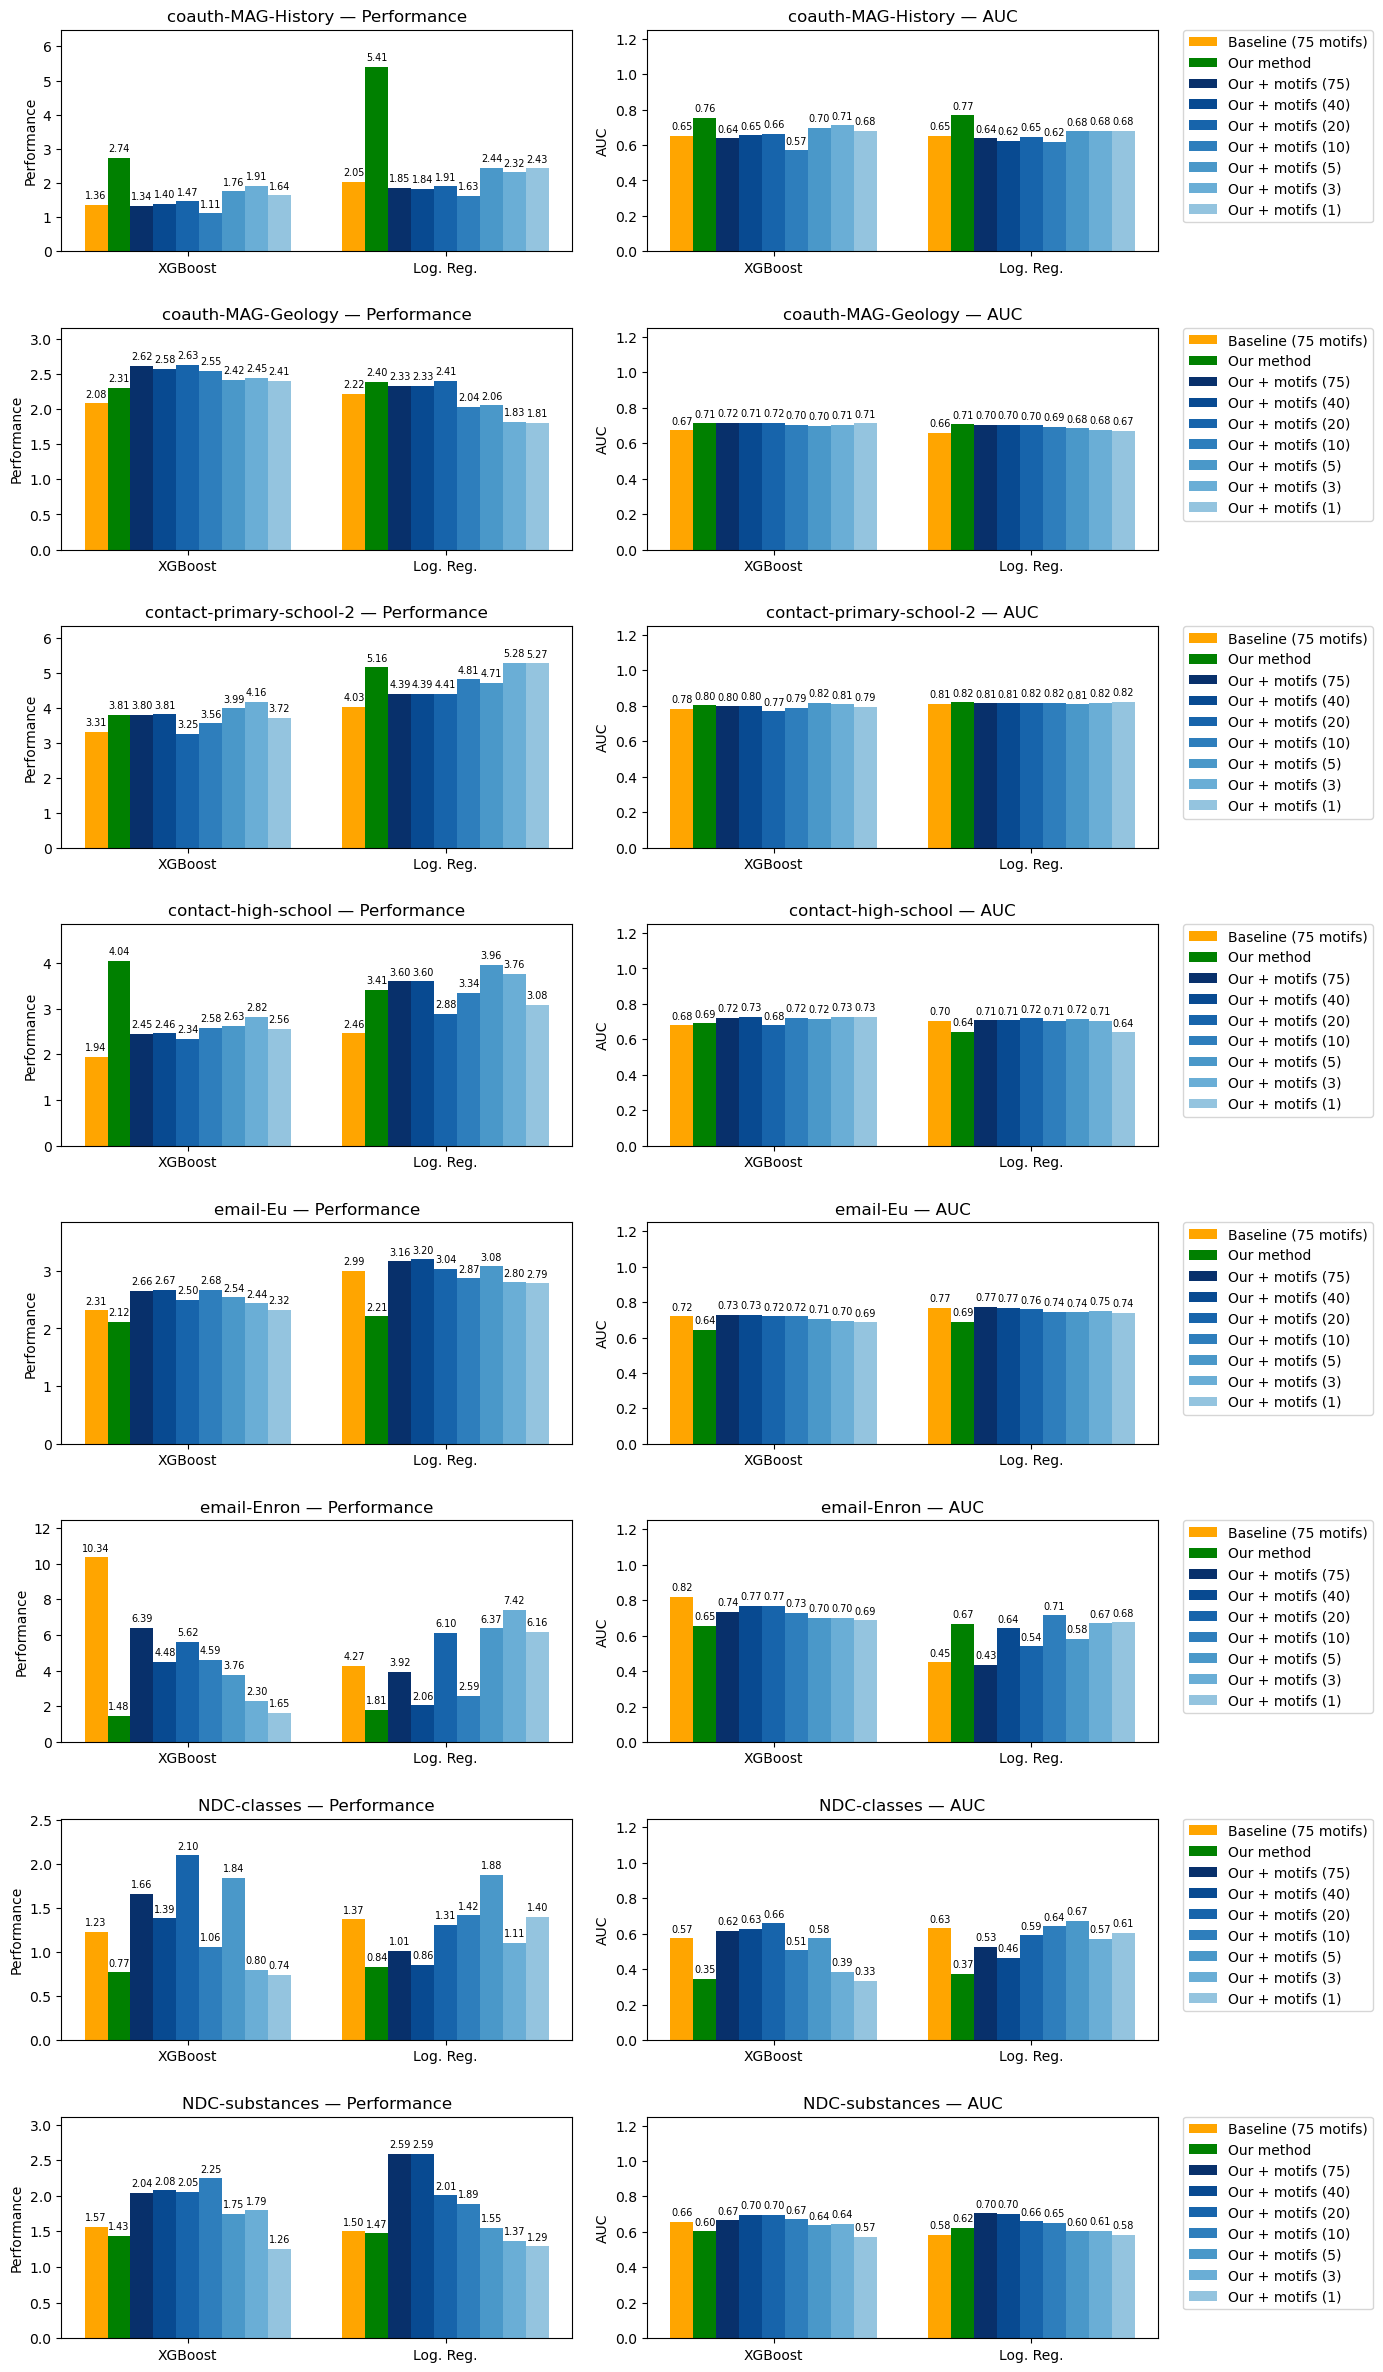

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from pathlib import Path

# Datasets and methods
datasets = [
    "coauth-MAG-History",
    "coauth-MAG-Geology",
    "contact-primary-school-2",
    "contact-high-school",
    "email-Eu",
    "email-Enron",
    "NDC-classes",
    "NDC-substances",
    # "tags-ask-ubuntu",
    # "threads-ask-ubuntu"
]
methods = ["xgb", "lr"]
method_labels = ["XGBoost", "Log. Reg."]
metrics = ["performance", "auc"]
metric_labels = {"performance": "Performance", "auc": "AUC"}

# Your comment suggested reversing this order for the plot (1 to 75), 
# but I kept your original list order.
motif_numbers = [75, 40, 20, 10, 5, 3, 1] 

# Base paths
our_base = Path("results_our/time")
our_motifs_base = Path("results_our_and_motifs/time")
baseline_base = Path("baseline/results_baseline/time")

def read_metrics(path: Path):
    # Added basic error handling for missing files
    if not path.exists():
        return {"performance": 0, "auc": 0}
    df = pd.read_csv(path)
    return df.iloc[0].to_dict()

# --- Collect Data ---
data = []
for dataset in datasets:
    for method in methods:
        # Construct paths
        our_path = our_base / dataset / "metrics" / f"test_{method}.csv"
        base_path = baseline_base / dataset / "metrics" / f"test_{method}.csv"

        our_metrics = read_metrics(our_path)
        base_metrics = read_metrics(base_path)

        # Append "Our"
        data.append({
            "dataset": dataset,
            "method": method,
            "type": "our",
            "performance": our_metrics["performance"],
            "auc": our_metrics["auc"],
        })
        
        # Append "Baseline"
        data.append({
            "dataset": dataset,
            "method": method,
            "type": "baseline",
            "performance": base_metrics["performance"],
            "auc": base_metrics["auc"],
        })

        # Append "Motifs"
        for n_motifs in motif_numbers:
            our_motifs_path = our_motifs_base / dataset / "metrics" / f"test_{method}_{n_motifs}.csv"
            our_motifs_metrics = read_metrics(our_motifs_path)
            data.append({
                "dataset": dataset,
                "method": method,
                "type": f"our_motifs_{n_motifs}",
                "performance": our_motifs_metrics["performance"],
                "auc": our_motifs_metrics["auc"],
            })
        
df = pd.DataFrame(data)

# --- Plotting ---
fig, axes = plt.subplots(nrows=len(datasets), ncols=2, figsize=(14, 24))
fig.subplots_adjust(hspace=0.6, wspace=0.3)

num_groups = len(methods) 
items_per_group = 1 + 1 + len(motif_numbers) 
total_width = 0.8
bar_width = total_width / items_per_group
x = np.arange(num_groups)

motif_colors = cm.Blues(np.linspace(1, 0.4, len(motif_numbers)))

for i, dataset in enumerate(datasets):
    for j, metric in enumerate(metrics):
        ax = axes[i, j]
        dataset_df = df[df["dataset"] == dataset]
        
        current_bar_idx = 0
        center_offset = (items_per_group - 1) / 2

        # 1. Plot Baseline
        base_vals = [
            dataset_df[(dataset_df["method"] == m) & (dataset_df["type"] == "baseline")][metric].values[0]
            for m in methods
        ]
        pos = x + (current_bar_idx - center_offset) * bar_width
        ax.bar(pos, base_vals, bar_width, label="Baseline (75 motifs)", color="orange")
        current_bar_idx += 1

        # 2. Plot Our Method
        our_vals = [
            dataset_df[(dataset_df["method"] == m) & (dataset_df["type"] == "our")][metric].values[0]
            for m in methods
        ]
        pos = x + (current_bar_idx - center_offset) * bar_width
        ax.bar(pos, our_vals, bar_width, label="Our method", color="green")
        current_bar_idx += 1

        # 3. Plot Motifs
        for k, n_motifs in enumerate(motif_numbers):
            motif_vals = [
                dataset_df[(dataset_df["method"] == m) & (dataset_df["type"] == f"our_motifs_{n_motifs}")][metric].values[0]
                for m in methods
            ]
            
            pos = x + (current_bar_idx - center_offset) * bar_width
            ax.bar(
                pos, 
                motif_vals, 
                bar_width, 
                label=f"Our + motifs ({n_motifs})", 
                color=motif_colors[k]
            )
            current_bar_idx += 1

        # Formatting
        ax.set_title(f"{dataset} — {metric_labels[metric]}")
        ax.set_xticks(x)
        ax.set_xticklabels(method_labels)
        ax.set_ylabel(metric_labels[metric])

        # --- FIX: Handle scaling per metric type ---
        if metric == "auc":
            # AUC is strictly 0-1, so we keep the fixed limit
            ax.set_ylim(0, 1.25) 
        else:
            # Performance is unbounded; we remove the hard limit.
            # We add a Y-margin (e.g., 20%) to ensure space for the labels above the tallest bar.
            ax.margins(y=0.2) 

        # Annotations
        for container in ax.containers:
            # fmt='%.2f' rounds to 2 decimals. Change if needed.
            ax.bar_label(container, fmt='%.2f', fontsize=7, rotation=0, padding=3)

        # Legend (First row only)
        if j == 1:
            ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout()
plt.savefig('n_motifs.pdf', format="pdf", bbox_inches="tight")
plt.show()


In [ ]:
from pypdf import PdfReader, PdfWriter, PageObject

def create_grid_pdf_from_list(pdf_paths, output_path, n_rows=3, n_cols=5):
    # pdf_paths: list of strings or Path objects, length should be n_rows * n_cols

    if len(pdf_paths) != n_rows * n_cols:
        print(f"Warning: Got {len(pdf_paths)} paths, expected {n_rows * n_cols}")

    # Read pages
    pages = []
    for p in pdf_paths:
        reader = PdfReader(str(p))
        pages.append(reader.pages[0])

    # Dimensions from first page
    first_page = pages[0]
    cell_w = float(first_page.mediabox.width)
    cell_h = float(first_page.mediabox.height)

    out_w = n_cols * cell_w
    out_h = n_rows * cell_h

    writer = PdfWriter()
    grid_page = PageObject.create_blank_page(width=out_w, height=out_h)

    for idx, src in enumerate(pages):
        row = idx // n_cols
        col = idx % n_cols

        x = col * cell_w
        y = (n_rows - 1 - row) * cell_h

        grid_page.merge_transformed_page(src, [1, 0, 0, 1, x, y])

    writer.add_page(grid_page)

    with open(output_path, "wb") as f:
        writer.write(f)

# Example usage: explicit array of files
files = [
    "results_our/time/coauth-MAG-Geology/metrics/shap_lr.pdf",
    "results_our/time/coauth-MAG-Geology/metrics/shap_xgb.pdf",
    "results_our/time/coauth-MAG-Geology/metrics/shap_rf.pdf",
    "results_our/time/coauth-MAG-History/metrics/shap_lr.pdf",
    "results_our/time/coauth-MAG-History/metrics/shap_xgb.pdf",
    "results_our/time/coauth-MAG-History/metrics/shap_rf.pdf",
    "results_our/time/contact-high-school/metrics/shap_lr.pdf",
    "results_our/time/contact-high-school/metrics/shap_xgb.pdf",
    "results_our/time/contact-high-school/metrics/shap_rf.pdf",
    "results_our/time/contact-primary-school-2/metrics/shap_lr.pdf",
    "results_our/time/contact-primary-school-2/metrics/shap_xgb.pdf",
    "results_our/time/contact-primary-school-2/metrics/shap_rf.pdf",
    "results_our/time/email-Eu/metrics/shap_lr.pdf",
    "results_our/time/email-Eu/metrics/shap_xgb.pdf",
    "results_our/time/email-Eu/metrics/shap_rf.pdf",
    "results_our/time/email-Enron/metrics/shap_lr.pdf",
    "results_our/time/email-Enron/metrics/shap_xgb.pdf",
    "results_our/time/email-Enron/metrics/shap_rf.pdf",
    "results_our/time/NDC-classes/metrics/shap_lr.pdf",
    "results_our/time/NDC-classes/metrics/shap_xgb.pdf",
    "results_our/time/NDC-classes/metrics/shap_rf.pdf",
    "results_our/time/NDC-substances/metrics/shap_lr.pdf",
    "results_our/time/NDC-substances/metrics/shap_xgb.pdf",
    "results_our/time/NDC-substances/metrics/shap_rf.pdf",
]

files_motifs = [
    "results_our_and_motifs/time/coauth-MAG-Geology/metrics/shap_lr.pdf",
    "results_our_and_motifs/time/coauth-MAG-Geology/metrics/shap_xgb.pdf",
    "results_our_and_motifs/time/coauth-MAG-Geology/metrics/shap_rf.pdf",
    "results_our_and_motifs/time/coauth-MAG-History/metrics/shap_lr.pdf",
    "results_our_and_motifs/time/coauth-MAG-History/metrics/shap_xgb.pdf",
    "results_our_and_motifs/time/coauth-MAG-History/metrics/shap_rf.pdf",
    "results_our_and_motifs/time/contact-high-school/metrics/shap_lr.pdf",
    "results_our_and_motifs/time/contact-high-school/metrics/shap_xgb.pdf",
    "results_our_and_motifs/time/contact-high-school/metrics/shap_rf.pdf",
    "results_our_and_motifs/time/contact-primary-school-2/metrics/shap_lr.pdf",
    "results_our_and_motifs/time/contact-primary-school-2/metrics/shap_xgb.pdf",
    "results_our_and_motifs/time/contact-primary-school-2/metrics/shap_rf.pdf",
    "results_our_and_motifs/time/email-Eu/metrics/shap_lr.pdf",
    "results_our_and_motifs/time/email-Eu/metrics/shap_xgb.pdf",
    "results_our_and_motifs/time/email-Eu/metrics/shap_rf.pdf",
    "results_our_and_motifs/time/email-Enron/metrics/shap_lr.pdf",
    "results_our_and_motifs/time/email-Enron/metrics/shap_xgb.pdf",
    "results_our_and_motifs/time/email-Enron/metrics/shap_rf.pdf",
    "results_our_and_motifs/time/NDC-classes/metrics/shap_lr.pdf",
    "results_our_and_motifs/time/NDC-classes/metrics/shap_xgb.pdf",
    "results_our_and_motifs/time/NDC-classes/metrics/shap_rf.pdf",
    "results_our_and_motifs/time/NDC-substances/metrics/shap_lr.pdf",
    "results_our_and_motifs/time/NDC-substances/metrics/shap_xgb.pdf",
    "results_our_and_motifs/time/NDC-substances/metrics/shap_rf.pdf",
]

create_grid_pdf_from_list(files, "grid_our.pdf", n_rows=8, n_cols=3)
create_grid_pdf_from_list(files_motifs, "grid_our_and_motifs.pdf", n_rows=8, n_cols=3)
